In [ ]:
import numpy as np
import tensorflow as tf
import os
import imageio
import matplotlib.pyplot as plt
import kagglehub

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Dropout,
    Conv2DTranspose,
    concatenate
)

from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

In [ ]:

dataset_path = kagglehub.dataset_download(
    "wobotintelligence/face-mask-detection-dataset"
)

print("Dataset Path:", dataset_path)

# ============================================
# CHECK DATASET CONTENTS
# ============================================

for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Files:", files[:5])
    print("-" * 50)
    break

Using Colab cache for faster access to the 'face-mask-detection-dataset' dataset.
Dataset Path: /kaggle/input/face-mask-detection-dataset
Folder: /kaggle/input/face-mask-detection-dataset
Files: ['submission.csv', 'train.csv']
--------------------------------------------------


In [ ]:

image_paths = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(root, file))

print("Total Images Found:", len(image_paths))


Total Images Found: 6024


In [ ]:
print("\nDataset folders:")
print(os.listdir(dataset_path))


Dataset folders:
['submission.csv', 'train.csv', 'Medical mask']


/tmp/ipykernel_1759/3460072515.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  sample_image = imageio.imread(image_paths[0])


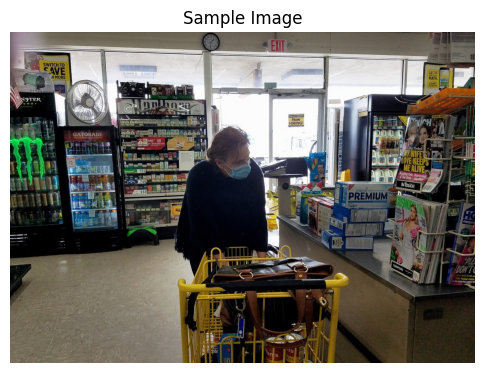

In [ ]:
sample_image = imageio.imread(image_paths[0])

plt.figure(figsize=(6,6))
plt.imshow(sample_image)
plt.title("Sample Image")
plt.axis("off")
plt.show()


In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_CHANNELS = 3

X = []

# Using first 100 images for demo
for path in image_paths[:100]:

    img = load_img(
        path,
        target_size=(IMG_HEIGHT, IMG_WIDTH)
    )

    img = img_to_array(img)
    img = img / 255.0

    X.append(img)

X = np.array(X)

print("Shape of X:", X.shape)

Shape of X: (100, 128, 128, 3)


In [ ]:
y = np.random.randint(
    0,
    2,
    (len(X), IMG_HEIGHT, IMG_WIDTH, 1)
)

print("Shape of y:", y.shape)


Shape of y: (100, 128, 128, 1)


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

# --------------------------------------------
# ENCODER
# --------------------------------------------

c1 = Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
c1 = Dropout(0.1)(c1)
c1 = Conv2D(16, (3,3), activation='relu', padding='same')(c1)
p1 = MaxPooling2D((2,2))(c1)

c2 = Conv2D(32, (3,3), activation='relu', padding='same')(p1)
c2 = Dropout(0.1)(c2)
c2 = Conv2D(32, (3,3), activation='relu', padding='same')(c2)
p2 = MaxPooling2D((2,2))(c2)

# --------------------------------------------
# BOTTLENECK
# --------------------------------------------

c3 = Conv2D(64, (3,3), activation='relu', padding='same')(p2)
c3 = Dropout(0.2)(c3)
c3 = Conv2D(64, (3,3), activation='relu', padding='same')(c3)

# --------------------------------------------
# DECODER
# --------------------------------------------

u4 = Conv2DTranspose(
    32,
    (2,2),
    strides=(2,2),
    padding='same'
)(c3)

u4 = concatenate([u4, c2])

c4 = Conv2D(32, (3,3), activation='relu', padding='same')(u4)
c4 = Dropout(0.1)(c4)
c4 = Conv2D(32, (3,3), activation='relu', padding='same')(c4)

u5 = Conv2DTranspose(
    16,
    (2,2),
    strides=(2,2),
    padding='same'
)(c4)

u5 = concatenate([u5, c1])

c5 = Conv2D(16, (3,3), activation='relu', padding='same')(u5)
c5 = Dropout(0.1)(c5)
c5 = Conv2D(16, (3,3), activation='relu', padding='same')(c5)

# --------------------------------------------
# OUTPUT LAYER
# --------------------------------------------

outputs = Conv2D(
    1,
    (1,1),
    activation='sigmoid'
)(c5)

# ============================================
# CREATE MODEL
# ============================================

model = Model(inputs=[inputs], outputs=[outputs])


In [ ]:
# ============================================
# COMPILE MODEL
# ============================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ============================================
# MODEL SUMMARY
# ============================================

model.summary()

# ============================================
# TRAIN MODEL
# ============================================

results = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    batch_size=8,
    epochs=10
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │        448 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128, 128,  │          0 │ conv2d_22[0][0]   │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 128, 128,  │      2,320 │ dropout_10[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ conv2d_23[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64, 64,    │          0 │ conv2d_24[0][0]   │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 64, 64,    │      9,248 │ dropout_11[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 32, 32,    │          0 │ conv2d_26[0][0]   │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 32, 32,    │     36,928 │ dropout_12[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 64, 64,    │      8,224 │ conv2d_27[0][0]   │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 64, 64,    │     18,464 │ concatenate_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 64, 64,    │          0 │ conv2d_28[0][0]   │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 64, 64,    │      9,248 │ dropout_13[0][0]

 Total params: 117,041 (457.19 KB)

 Trainable params: 117,041 (457.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 169ms/step - accuracy: 0.4998 - loss: 0.6932 - val_accuracy: 0.4979 - val_loss: 0.6932
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5011 - loss: 0.6931 - val_accuracy: 0.5013 - val_loss: 0.6931
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5004 - loss: 0.6931 - val_accuracy: 0.5015 - val_loss: 0.6931
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5012 - loss: 0.6931 - val_accuracy: 0.4999 - val_loss: 0.6931
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5010 - loss: 0.6931 - val_accuracy: 0.4998 - val_loss: 0.6931
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5018 - loss: 0.6931 - val_accuracy: 0.5009 - val_loss: 0.6931
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5017 - loss: 0.6931 - val_accuracy: 0.5005 - val_loss: 0.6932
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5025 - loss: 0.6931 - val_accuracy: 0.4993 -

In [ ]:
# ============================================
# EVALUATE MODEL
# ============================================

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.6932
Test Loss: 0.6931573748588562
Test Accuracy: 0.4999542236328125


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


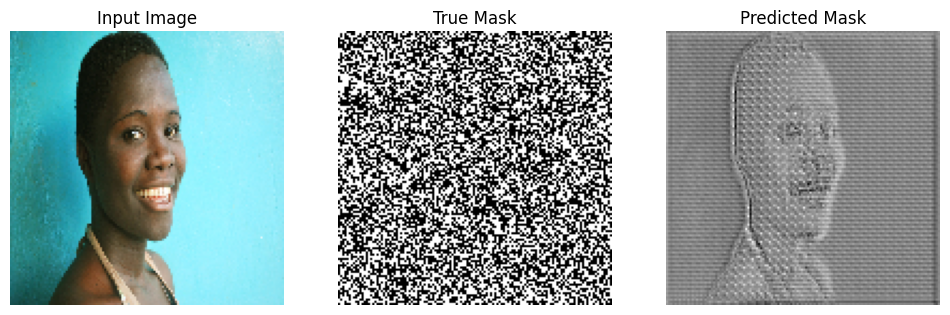

In [ ]:
# ============================================
# PREDICTIONS
# ============================================

predictions = model.predict(X_test)

# ============================================
# SHOW PREDICTION
# ============================================

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_test[0])
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(y_test[0].squeeze(), cmap='gray')
plt.title("True Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(predictions[0].squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()